# Health Data with SNOWMED code of all interactions

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from pandas_gbq import read_gbq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
import pandas as pd
import contextily as cx

In [3]:
sns.set(rc={'figure.figsize':(11, 4)})

In [4]:
query = """
WITH RankedEvents AS (
  SELECT 
    t1.person_id,
    PARSE_TIMESTAMP('%b %d %Y %I:%M%p', t1.event_date) AS event_timestamp,
    t1.SNOMEDCode, 
    t1.SNOMEDText,
    t2.LSOA,
    ROW_NUMBER() OVER (
      PARTITION BY t1.person_id, t1.event_date, t1.SNOMEDCode, t1.SNOMEDText, t2.LSOA 
      ORDER BY t1.event_date
    ) AS rn
  FROM `yhcr-prd-bradfor-bia-core.CB_2797_PoliceMentalHealth.distinctRecordsPerConditionDatetime` t1
  JOIN `yhcr-prd-bradfor-bia-core.CB_2797_PoliceMentalHealth.personLSOA` t2 
    ON t1.person_id = t2.person_id
  WHERE t2.LSOA IS NOT NULL 
    AND t2.LSOA <> '' 
)
SELECT person_id, DATE(event_timestamp), COUNT(DISTINCT SNOMEDCode) AS distinct_snomed_count, LSOA
FROM RankedEvents
WHERE rn = 1
GROUP BY person_id, DATE(event_timestamp), LSOA
ORDER BY DATE(event_timestamp)
"""

In [5]:
df_lsoa_person_time = read_gbq(query, project_id="yhcr-prd-bradfor-bia-core", use_bqstorage_api=False)
df_lsoa_person_time.head(2)

Downloading: 100%|██████████|


,person_id,f0_,distinct_snomed_count,LSOA
0,2A55C45573E8BF3955A3F3955659D9C023A50BE1B47D0B...,2017-04-01,1,E01010832
1,0ACB2BDEC9F27713F69AC9C374627B1D52435C0DD0AFF3...,2017-04-01,1,E01010599


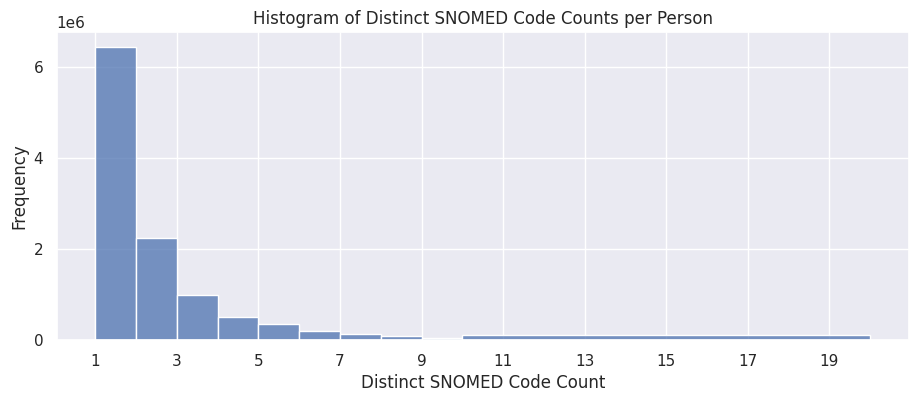

In [6]:
custom_bins = [1,2,3, 4,5, 6,7, 8,9, 10,20]
sns.histplot(data=df_lsoa_person_time, x='distinct_snomed_count', bins=custom_bins, kde=False)

plt.xlabel('Distinct SNOMED Code Count')
plt.ylabel('Frequency')
y_max = df_lsoa_person_time['distinct_snomed_count'].value_counts().max()
plt.yticks(range(0, y_max + 1,2000000))
plt.xticks(range(1, 21,2))
plt.title('Histogram of Distinct SNOMED Code Counts per Person')


plt.show()

In [7]:
df_lsoa_person_time['distinct_snomed_count'].value_counts()

distinct_snomed_count
1     6444576
2     2245054
3      983678
4      507815
5      348822
       ...   
64          1
72          1
59          1
62          1
73          1
Name: count, Length: 67, dtype: Int64

In [44]:
df_lsoa_person_time[df_lsoa_person_time['distinct_snomed_count']==1].shape

(6444576, 4)